In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("Final_Sales_Pipeline.csv")

In [8]:
df.head(11)

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,won,2016-10-25,2017-03-02,517.0
5,ZNBS69V1,Anna Snelling,MG Special,Ron-tech,won,2016-10-29,2017-03-01,49.0
6,9ME3374G,Vicki Laflamme,MG Special,J-Texon,won,2016-10-30,2017-03-02,57.0
7,7GN8Q4LL,Markita Hansen,GTX Basic,Cheers,won,2016-11-01,2017-03-07,601.0
8,OLK9LKZB,Niesha Huffines,GTX Plus Basic,Zumgoity,won,2016-11-01,2017-03-03,1026.0
9,HAXMC4IX,James Ascencio,MG Advanced,NaN,engaging,2016-11-03,NaN,0.0


In [9]:
total_revenue = df['close_value'].sum()

In [10]:
total_deals=df.shape[0]

In [11]:
closed_won = df[df['stage']=='closed_won'].shape[0]

KeyError: 'stage'

In [ ]:
print(df.columns)

In [ ]:
closed_won = df[df['deal_stage']=='closed won'].shape[0]

In [ ]:
df['deal_stage'] = df['deal_stage'].str.strip().str.lower()

In [ ]:
total_deals = df.shape[0]

In [12]:
closed_won = df[df['deal_stage'] == 'closed_won'].shape[0]

In [13]:
conversion_rate = closed_won/total_deals

In [14]:
df['deal_stage'].value_counts()

deal_stage
won            4238
lost           2473
engaging       1589
prospecting     500
Name: count, dtype: int64

In [15]:
stage_order =['prospecting','engaging','won','lost|']

In [16]:
df['deal_stage'] = pd.Categorical(df['deal_stage'],categories=stage_order,ordered =True)

In [17]:
stage_counts = df['deal_stage'].value_counts().sort_index()

In [18]:
print(stage_counts)

deal_stage
prospecting     500
engaging       1589
won            4238
lost|             0
Name: count, dtype: int64


In [19]:
import matplotlib.pyplot as plt


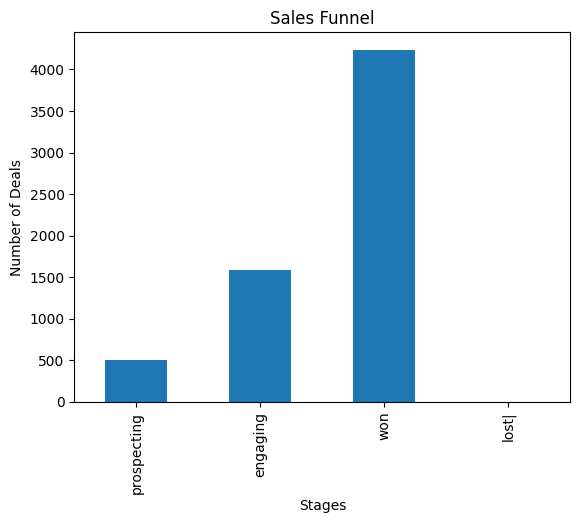

In [20]:
stage_counts.plot(kind='bar')
plt.title("Sales Funnel")
plt.xlabel("Stages")
plt.ylabel("Number of Deals")
plt.show()

In [21]:
prospecting = stage_counts['prospecting']

In [22]:
engaging = stage_counts['engaging']

In [23]:
conv1 = engaging/prospecting

In [24]:
won = stage_counts['won']

In [25]:
conv2 = won / engaging

In [26]:
total_deals = df.shape[0]

In [27]:
overall_conversion = won / total_deals

In [28]:
funnel_percent = (stage_counts/stage_counts.sum())*100

In [29]:
print(funnel_percent)

deal_stage
prospecting     7.902639
engaging       25.114588
won            66.982772
lost|           0.000000
Name: count, dtype: float64


In [30]:
total_revenue = df['close_value'].sum()

In [31]:
print(total_revenue)

10005534.0


In [32]:
df.groupby('deal_stage')['close_value'].sum()

C:\Users\Bappi\AppData\Local\Temp\ipykernel_21864\486159865.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('deal_stage')['close_value'].sum()


deal_stage
prospecting           0.0
engaging              0.0
won            10005534.0
lost|                 0.0
Name: close_value, dtype: float64

In [33]:
df['close_value'].mean()

1136.9925

In [34]:
df['close_date'] = pd.to_datetime(df['close_date'])

<Axes: xlabel='close_date'>

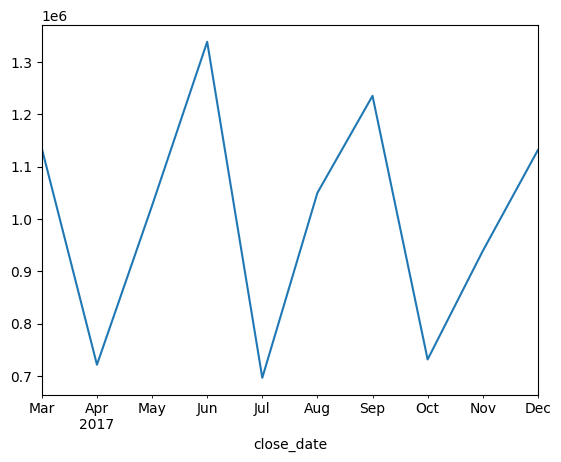

In [35]:
df.groupby(df['close_date'].dt.to_period('M'))['close_value'].sum().plot()

In [36]:
from scipy.stats import ttest_ind

won = df[df['deal_stage'] == 'won']['close_value']
lost = df[df['deal_stage'] == 'lost']['close_value']

t_stat, p_value = ttest_ind(won, lost, nan_policy='omit')

print("P-value:", p_value)

P-value: nan


C:\Users\Bappi\miniconda3\envs\torch_env\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [37]:
print("Won count:", len(won))
print("Lost count:", len(lost))

Won count: 4238
Lost count: 0


In [38]:
df['close_date'] = pd.to_datetime(df['close_date'])
df['engage_date'] = pd.to_datetime(df['engage_date'])

df['deal_duration'] = (df['close_date'] - df['engage_date']).dt.days

won = df[df['deal_stage'] == 'won']['deal_duration'].dropna()
lost = df[df['deal_stage'] == 'lost']['deal_duration'].dropna()

t_stat, p_value = ttest_ind(won, lost, nan_policy='omit')

print("P-value:", p_value)

P-value: nan


C:\Users\Bappi\miniconda3\envs\torch_env\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [39]:
print("Won count:", len(won))
print("Lost count:", len(lost))

Won count: 4238
Lost count: 0


In [40]:
df[['deal_stage', 'engage_date', 'close_date', 'deal_duration']].head(10)

,deal_stage,engage_date,close_date,deal_duration
0,won,2016-10-20,2017-03-01,132.0
1,won,2016-10-25,2017-03-11,137.0
2,won,2016-10-25,2017-03-07,133.0
3,won,2016-10-25,2017-03-09,135.0
4,won,2016-10-25,2017-03-02,128.0
5,won,2016-10-29,2017-03-01,123.0
6,won,2016-10-30,2017-03-02,123.0
7,won,2016-11-01,2017-03-07,126.0
8,won,2016-11-01,2017-03-03,122.0
9,engaging,2016-11-03,NaT,NaN


In [41]:
print(df['engage_date'].isna().sum())
print(df['close_date'].isna().sum())

500
2089


In [42]:
df_clean = df.dropna(subset=['engage_date', 'close_date'])

In [43]:
df_clean['deal_duration'] = (df_clean['close_date'] - df_clean['engage_date']).dt.days

won = df_clean[df_clean['deal_stage'] == 'won']['deal_duration']
lost = df_clean[df_clean['deal_stage'] == 'lost']['deal_duration']

print(len(won), len(lost))

4238 0


C:\Users\Bappi\AppData\Local\Temp\ipykernel_21864\3592769059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['deal_duration'] = (df_clean['close_date'] - df_clean['engage_date']).dt.days


In [44]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(won, lost, nan_policy='omit')

print("P-value:", p_value)

P-value: nan


C:\Users\Bappi\miniconda3\envs\torch_env\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [45]:
from statsmodels.stats.proportion import proportions_ztest

won_count = df[df['deal_stage'] == 'won'].shape[0]
lost_count = df[df['deal_stage'] == 'lost'].shape[0]

count = [won_count]
nobs = [won_count + lost_count]

stat, p_value = proportions_ztest(count, nobs)

print("P-value:", p_value)

ValueError: value must be provided for a 1-sample test

In [46]:
from statsmodels.stats.proportion import proportions_ztest

won_count = df[df['deal_stage'] == 'won'].shape[0]
lost_count = df[df['deal_stage'] == 'lost'].shape[0]

count = [won_count, lost_count]
nobs = [won_count + lost_count, won_count + lost_count]

stat, p_value = proportions_ztest(count, nobs)

print("P-value:", p_value)

P-value: 0.0
